# **RANDOM FORES**

## **LIBRARIES**

In [225]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import randint
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler


## **DATA**

This dataset is the Pima Indians Diabetes Dataset, commonly used for binary classification tasks in machine learning. Dataset contains following data:
* pregnancies – number of times pregnant
* glucose – plasma glucose concentration
* pressure – diastolic blood pressure (mm Hg)
* skin – skin fold thickness (mm)
* insulin – 2-hour serum insulin (mu U/ml)
* bmi – body mass index
* pedigre – diabetes pedigree function (genetic likelihood)
* age – age in years
* class - indicator if it has or doesn't have diabetes

In [226]:
# Pima Indians Diabetes (pima-indians-diabetes.csv)
data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
data_headers = ['pregnancies', 'glucose', 'pressure', 'skin', 'insulin', 'bmi', 'pedigre', 'age', 'class']

data_frame = pd.read_csv(data_url, names = data_headers)

### **EXPLORING**

In [227]:
print("Dataset size: ", len(data_frame))
print("Dataset dimensions: ", data_frame.shape)

# Preview dataset
data_frame.head()
data_frame.tail()  # all rows are numeric

Dataset size:  768
Dataset dimensions:  (768, 9)


,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [228]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  768 non-null    int64  
 1   glucose      768 non-null    int64  
 2   pressure     768 non-null    int64  
 3   skin         768 non-null    int64  
 4   insulin      768 non-null    int64  
 5   bmi          768 non-null    float64
 6   pedigre      768 non-null    float64
 7   age          768 non-null    int64  
 8   class        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [229]:
data_frame.nunique()

pregnancies     17
glucose        136
pressure        47
skin            51
insulin        186
bmi            248
pedigre        517
age             52
class            2
dtype: int64

In [230]:
data_frame['class'].isin([0, 1]).all()  # binary variable

np.True_

Dataset's *class* variable is a **binary variable**, goal of the model is to predict it based on other feature variables.

### **CLEANING**

In [231]:
# replacing missing values with NaN
data_frame[['glucose', 'pressure', 'skin', 'insulin', 'bmi']] = data_frame[
    ['glucose', 'pressure', 'skin', 'insulin', 'bmi']].replace(0, np.nan)
data_frame.head()

,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [232]:
pd.DataFrame({
    'existing': data_frame.notnull().sum(),
    'missing': data_frame.isnull().sum()
})

,existing,missing
pregnancies,768,0
glucose,763,5
pressure,733,35
skin,541,227
insulin,394,374
bmi,757,11
pedigre,768,0
age,768,0
class,768,0


*Skin* and *insulin* has lots of missing data.

### **IMPUTING**

In [233]:
columns_with_missing_values = ['glucose', 'pressure', 'skin', 'insulin', 'bmi']

data_frame_with_missing_values = data_frame.dropna()

for column in columns_with_missing_values:
    print(f"Handling missing values for column: {column}")

    # testing for normal distribution
    # H0: data is normally distributed (p > 0.05)
    # H1: data is not normally distributed (p < 0.05)

    stat, p = shapiro(data_frame_with_missing_values[column])

    if p > 0.05:
        # replace missing data with mean value
        print(f"For column {column}: (W) = {stat}, p-value: {p} - replacing with mean")
        data_frame[column] = data_frame[column].fillna(data_frame[column].mean())
    else:
        # replace missing data with median value
        print(f"For column {column}: (W) = {stat}, p-value: {p} - replacing with median")
        data_frame[column] = data_frame[column].fillna(data_frame[column].median())

Handling missing values for column: glucose
For column glucose: (W) = 0.9642306956085971, p-value: 3.4419837597709915e-08 - replacing with median
Handling missing values for column: pressure
For column pressure: (W) = 0.989944082615475, p-value: 0.008711922485350096 - replacing with median
Handling missing values for column: skin
For column skin: (W) = 0.9875800258677621, p-value: 0.001991033072936546 - replacing with median
Handling missing values for column: insulin
For column insulin: (W) = 0.8040082005482936, p-value: 1.9034742632890465e-21 - replacing with median
Handling missing values for column: bmi
For column bmi: (W) = 0.9738408670856034, p-value: 1.6567937168597838e-06 - replacing with median


In [234]:
data_frame.head()

,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### **SPLITTING**

In [235]:
y = data_frame['class']
x = data_frame.drop('class', axis=1)  # axis = 1 - drop column

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)
# random_state = 0 to always get same split
# stratify y keeps same class ratio in train/test
np.unique(y_train, return_counts=True)

(array([0, 1]), array([400, 214]))

#### **Oversampling** ####

In [236]:
random_over_sampler = RandomOverSampler(random_state=42)

x_train_over, y_train_over = random_over_sampler.fit_resample(x_train, y_train)
np.unique(y_train_over, return_counts=True)

(array([0, 1]), array([400, 400]))

## **MODEL**

### **FIRST MODEL** - DEFAULT PARAMS

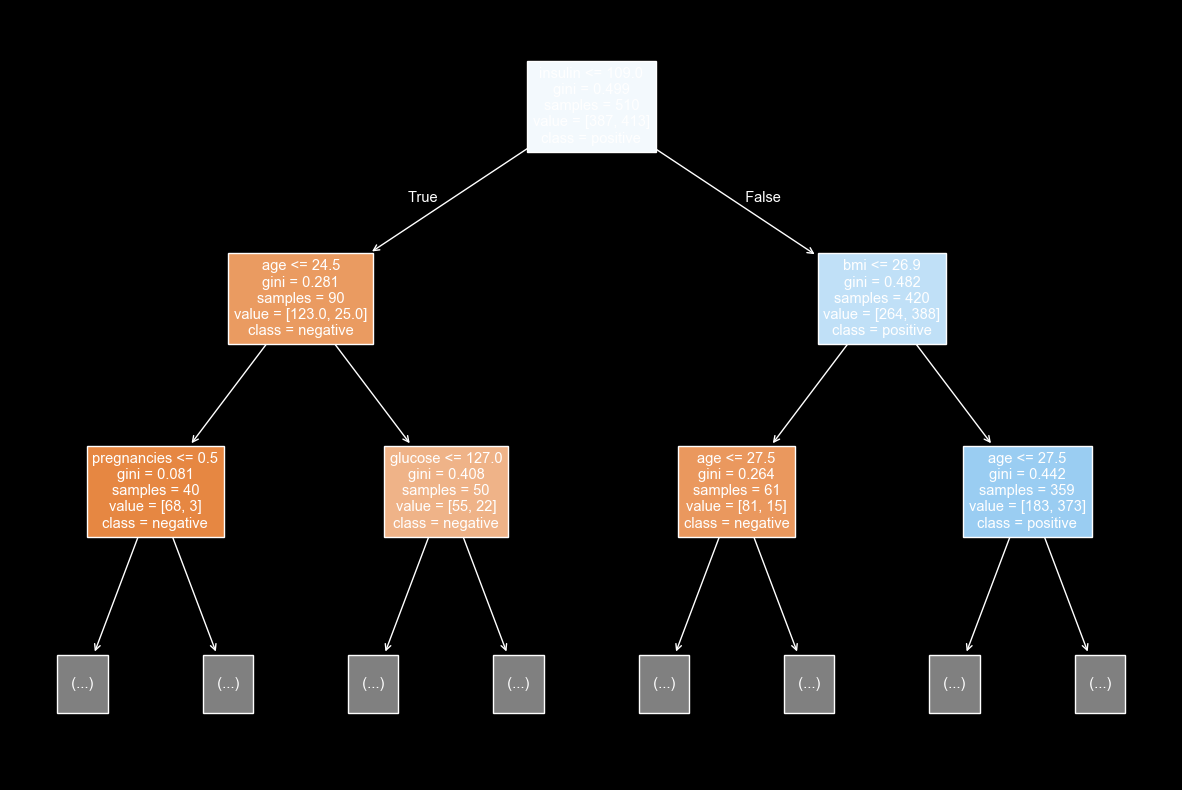

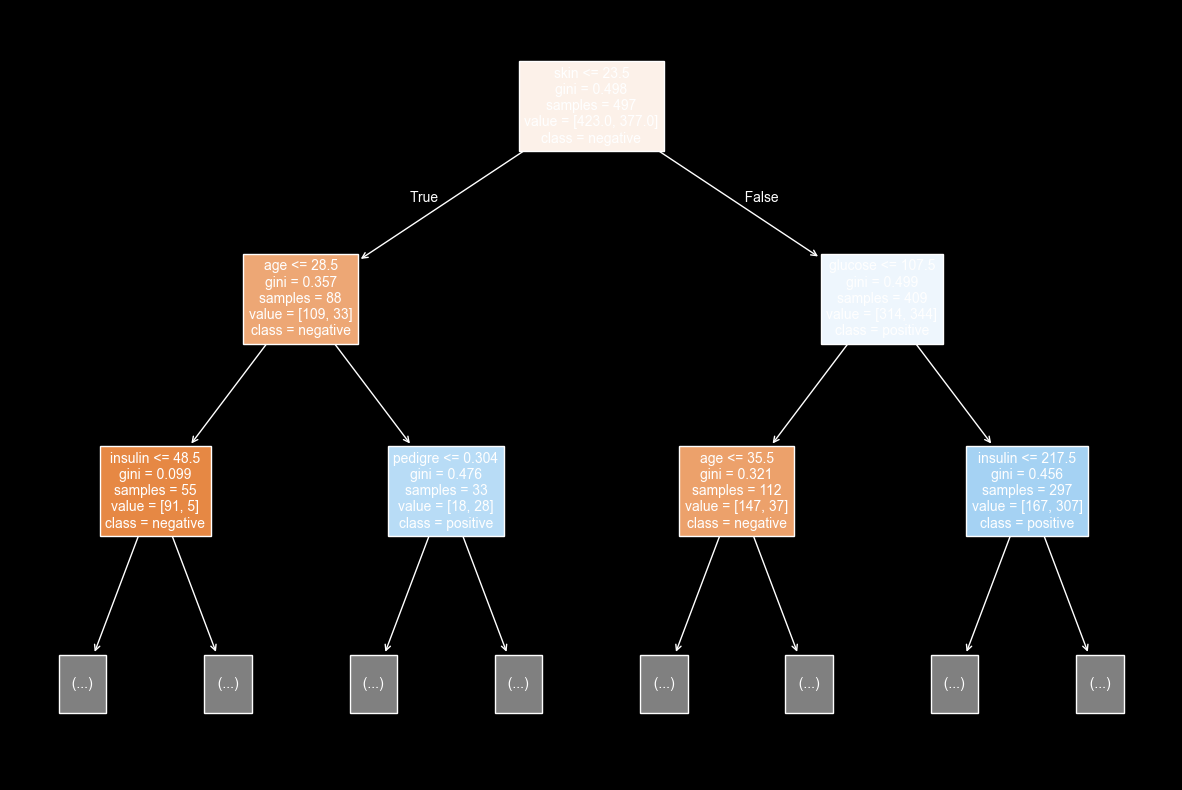

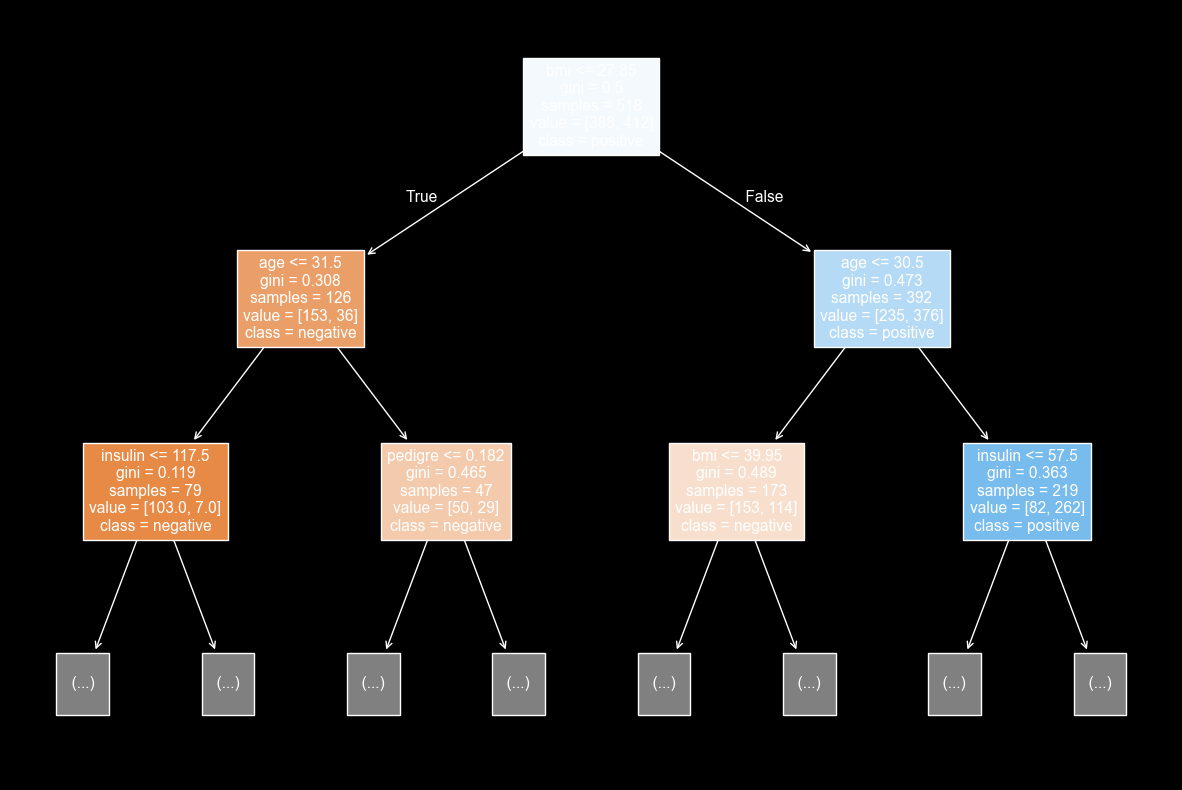

In [237]:
random_forest_default = RandomForestClassifier(random_state=0)
random_forest_default = random_forest_default.fit(x_train_over, y_train_over)

for estimator in random_forest_default.estimators_[:3]:
    fig = plt.figure(figsize=(15,10))
    plot_tree(estimator, feature_names = x_train.columns, class_names = ['negative', 'positive'], filled=True, max_depth=2)
    plt.show()

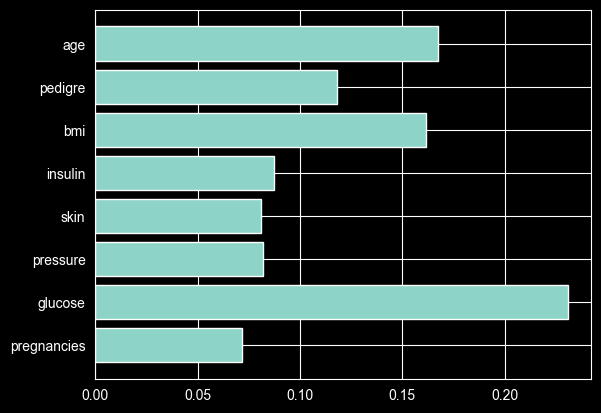

In [238]:
plt.barh(random_forest_default.feature_names_in_, random_forest_default.feature_importances_)
plt.show()

All variables are considered for this tree.

#### **FIRST MODEL** - DEFAULT PARAMS - PREDICT

In [239]:
y_random_forest_default_predict = random_forest_default.predict(x_test)
confusion_matrix(y_test, y_random_forest_default_predict)

array([[87, 13],
       [20, 34]])

In [240]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_random_forest_default_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.63      0.67        54

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



Model has accuracy **0.79**.

### **SECOND MODEL** - RANDOM PARAMS (RandomizedSearchCV)

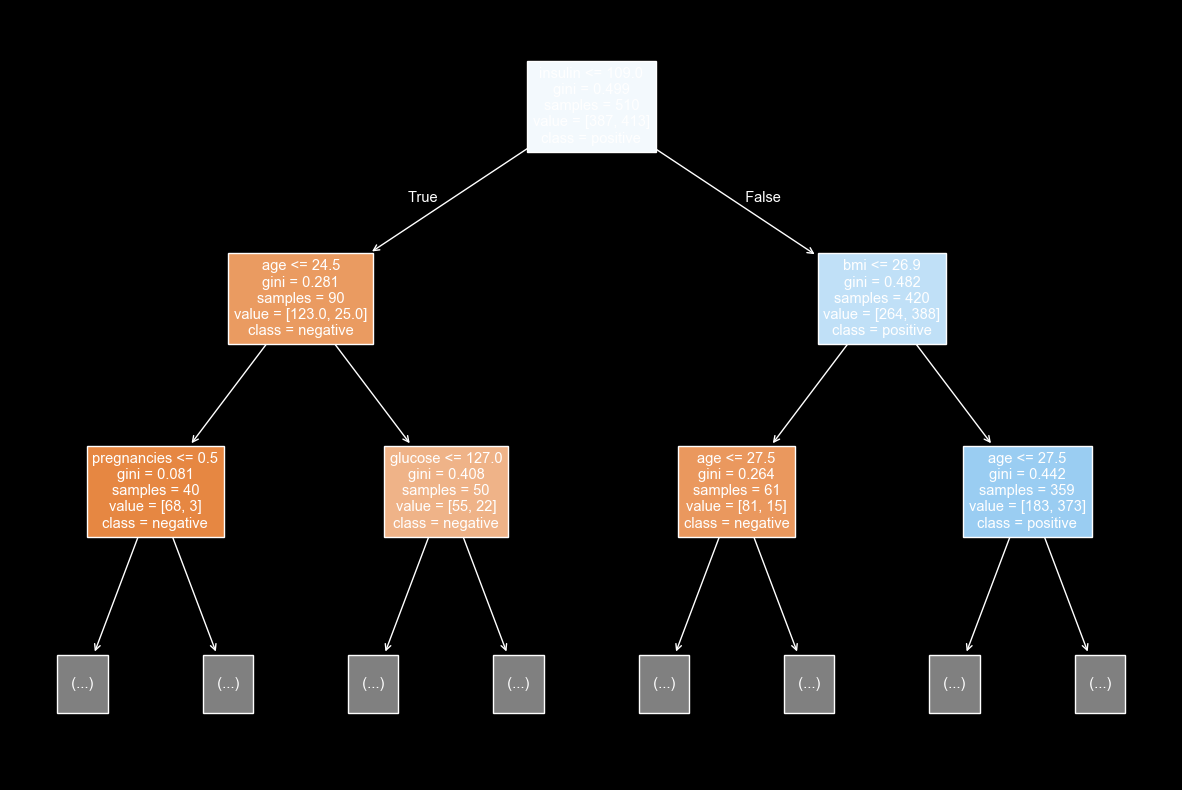

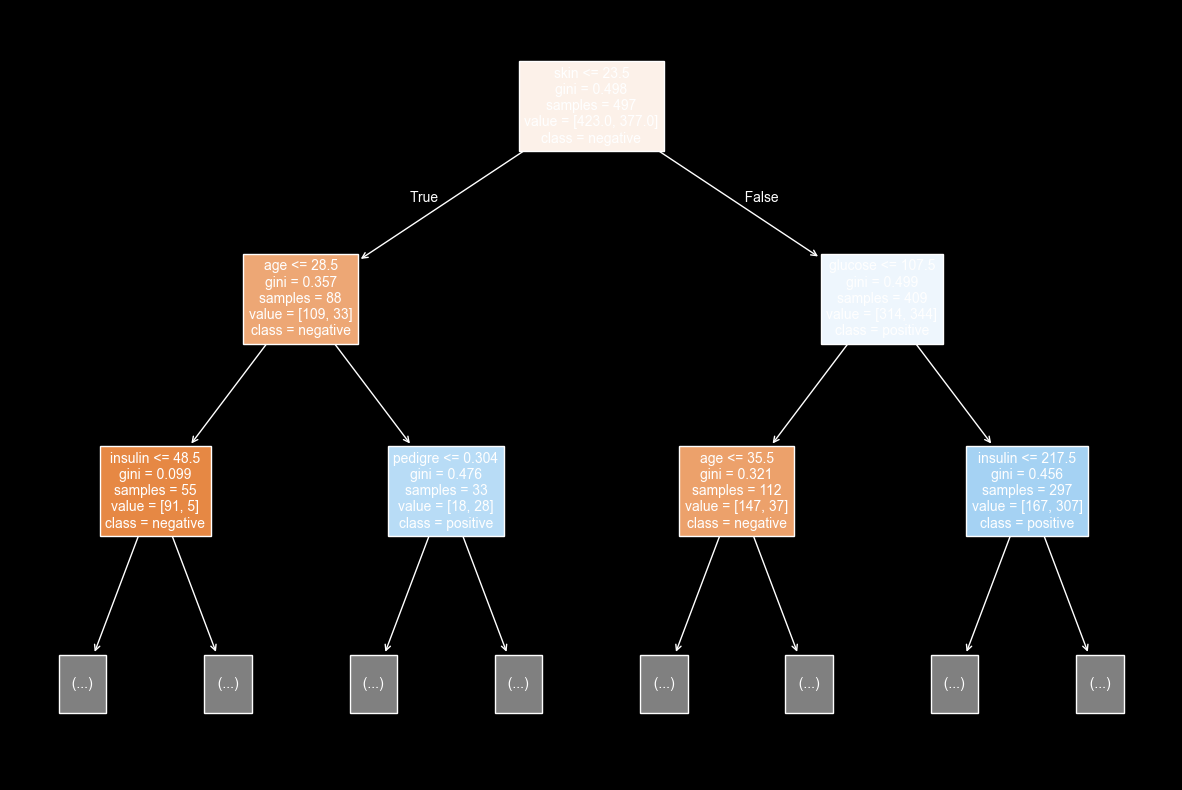

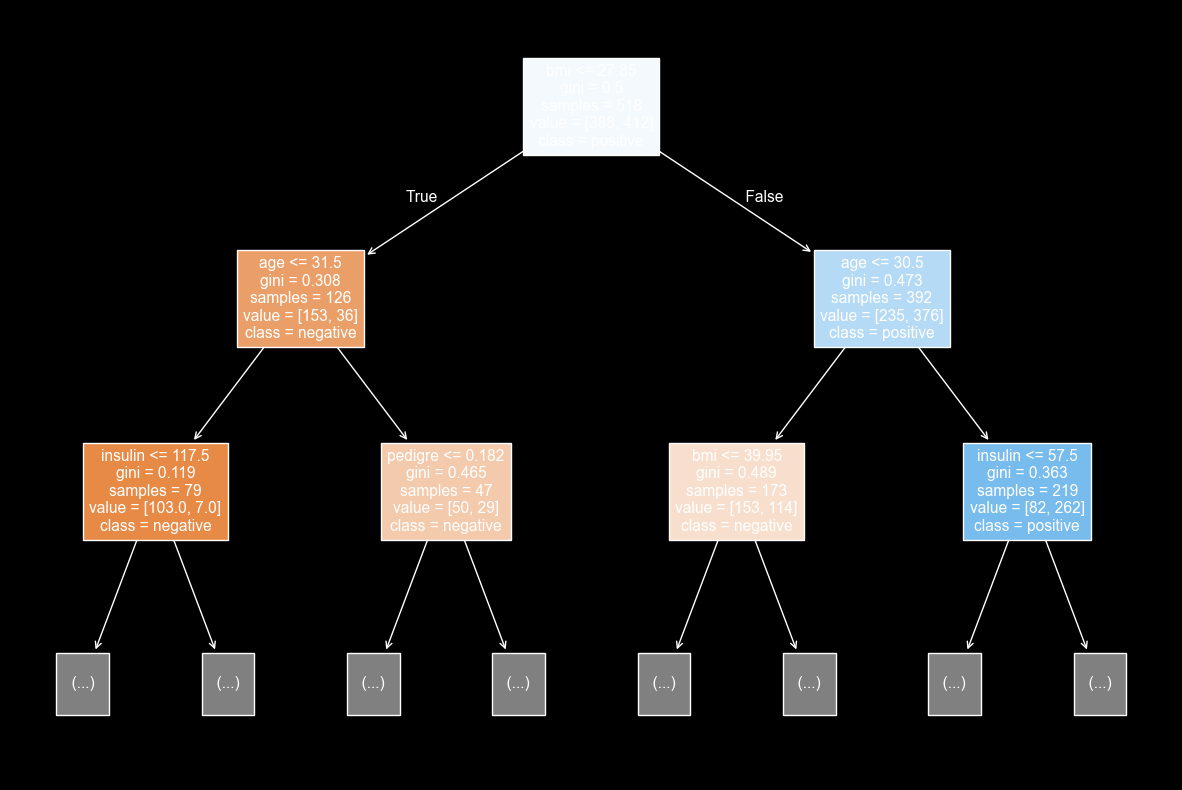

In [241]:
random_param_dist = {'n_estimators': randint(50,500), 'max_depth': randint(1,20)}

random_forest_classifier = RandomForestClassifier(random_state=0)
random_forest_search = RandomizedSearchCV(random_forest_classifier, param_distributions = param_dist, n_iter=5, cv=15,scoring='accuracy')

random_forest_search = random_forest_search.fit(x_train_over,y_train_over)
random_forest_search_best = random_forest_search.best_estimator_

for estimator in random_forest_search_best.estimators_[:3]:
    fig = plt.figure(figsize=(15,10))
    plot_tree(estimator, feature_names = x_train.columns, class_names = ['negative', 'positive'], filled=True, max_depth=2)
    plt.show()

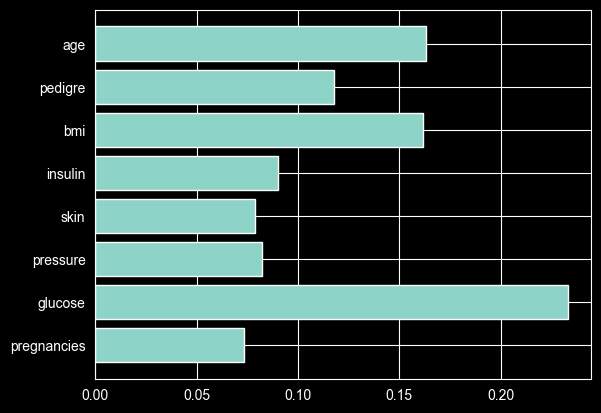

In [242]:
plt.barh(random_forest_search_best.feature_names_in_, random_forest_search_best.feature_importances_)
plt.show()

#### **SECOND MODEL** - RANDOM PARAMS (RandomizedSearchCV) - PREDICT

In [245]:
y_random_forest_predict_best = random_forest_search_best.predict(x_test)
confusion_matrix(y_test, y_random_forest_predict_best)

array([[88, 12],
       [20, 34]])

In [244]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_random_forest_predict_best))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       100
           1       0.74      0.63      0.68        54

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



Model has improved its accuracy to **0.81**.